In [1]:
%matplotlib inline

## Computer Vision
## Master in Machine Learning for Health - Universidad Carlos III de Madrid

# LAB SESSION 5: IMAGE CLASSIFICATION WITH CNNs

# AUTOMATIC DIAGNOSIS SYSTEM FOR DIABETIC RETINOPATHY

<center><img src='http://www.tsc.uc3m.es/~igonzalez/images/logo_uc3m_foot.jpg' width=400 /></center>

## Part 0: The problem
In this practice we are going to build a diabetic retinopahy diagnosis system based on image analysis.



Before starting the practice, we will briefly describe the database that we will use and the problem we aim to address:

Diabetic Retinopathy (DR) is the leading cause of blindness in the working-age population of the developed world. World Health Organization estimates that 347 million people have the disease worldwide. Diabetic Retinopathy (DR) is an eye disease associated with long-standing diabetes. Around 40% to 45% of Americans with diabetes have some stage of the disease. Progression to vision impairment can be slowed or averted if DR is detected in time, however this can be difficult as the disease often shows few symptoms until it is too late to provide effective treatment.

Our goal is to develop a CNN providing an automatic diagnosis of DR with color fundus photography as input. The need for a comprehensive and automated method of DR screening has long been recognized, and previous efforts have made good progress using image classification, pattern recognition, and machine learning.

You are provided with a large set of high-resolution retina images taken under a variety of imaging conditions. Left and right fields can be provided indistinctively. Images are labeled with the following data:

- 1.- An image id.
- 2.- An eye indicator (left,right)
- 3.- A label, indicating the presence of diabetic retinopathy in each image on a scale of 0 to 4, according to the following scale: 0 - No DR, 1 - Mild, 2 - Moderate, 3 - Severe, 4 - Proliferative DR

Figure 1 shows a visual example of a eye color fundus:

![Image of retina](https://www.tsc.uc3m.es/~igonzalez/images/retina.jpg)

The dataset contains 3500 images divided into 3 sets:
- Training set: 2000 images
- Validation set: 500 images
- Test set: 1000 images.

Additionally, there is a csv file for each dataset (training, validation and test) in which each lines corresponds with a clinical case, defined with two fields separated by commas:
- the numerical id of the lesion: that allows to build the paths to the image.
- 2.- An eye indicator (0-left eye and 1-right eye). It allows mirroring right-eye images so that both left and right eyes are comparable.
- the lesion label: available only for training and validation, being an integer between 0 and 4:  0 - No DR, 1 - Mild, 2 - Moderate, 3 - Severe, 4 - Proliferative DR. In the case of the test set, labels are not available (their value is -1).

For simplicity, we will transform the original labels to produce a binary label: 0 - No DR, 1 - DR. Therefore we tackle a binary classification problem.

Students will be able to use the training and validation sets to build their solutions and finally provide the scores associated with the test set. This practice provides guidelines to build a baseline reference system. To do so, we will learn two fundamental procedures:

1) Process your own database with PyTorch
2) Design a feedforward CNN that processess images and provides a diagnostic
3) Use a regular network that has been pretrained using a large-scale general purpose dataset and fine-tune it for our diagnostic problem


## Part 1: Handling our custom dataset with PyTorch
Now we are going to study how we can load and process our custom dataset in PyTorch. For that end, we are going to use the package ``scikit-image`` for reading images, and the package ``panda`` for reading csv files.


In [2]:
from __future__ import print_function, division
import os
import torch
import pandas as pd
from skimage import io, transform, util, color
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils, models
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy
from PIL import Image
import pdb
import random
import numpy.random as npr
import cv2

random.seed(42)
npr.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.enabled = False

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

plt.ion()   # interactive mode
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [3]:
# Data root: CSVs and images/ folder live at the project root (not ./data/)
DATA_ROOT = '/content/drive/MyDrive/CV/data'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


The first thing we need to do is to download and decompress the dataset on a local folder:




In [5]:
# ONLY TO USE GOOGLE COLAB. Run this code only the first time you run this notebook and then comment these lines
from shutil import copyfile
from google.colab import drive
import os, sys
drive.mount('/content/drive')
#copyfile('/content/drive/My Drive/Colab Notebooks/s4/db.zip', './db.zip') #Copy db files to our working folder

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# NOTE: Data already extracted - comment this cell out when data is available
import zipfile
zipPath='/content/drive/MyDrive/CV/LS5_CV_2025_2026_DB_Retinopathy.zip' #path of the 1st zip file
dataFolder='/content/drive/MyDrive/CV/data' # We extract files to the current folder
with zipfile.ZipFile(zipPath, 'r') as zip_ref:
   zip_ref.extractall(dataFolder)

In [73]:
# NOTE: Data already extracted - comment this cell out when data is available
import zipfile
zipPath='/content/drive/MyDrive/CV/cache_224-20260406T152553Z-3-001.zip' #path of the 1st zip file
dataFolder='/content/' # We extract files to the current folder
with zipfile.ZipFile(zipPath, 'r') as zip_ref:
   zip_ref.extractall(dataFolder)


Now let's read the indexed file and display data from image 65. The file structure is one row per image of the database, and two fields:
- Image ID (a 5-digit sequence, adding 0 to the left side if required)
- Label: 0 - No DR, 1 - Mild, 2 - Moderate, 3 - Severe, 4 - Proliferative DR
- Eye: 0 left eye, 1 right eye

The images in the dataset come from different models and types of cameras, which can affect the visual appearance of left vs. right. Like any real-world data set, you will encounter noise in both the images and labels. Images may contain artifacts, be out of focus, underexposed, or overexposed. A major aim of this competition is to develop robust algorithms that can function in the presence of noise and variation.



In [7]:
db = pd.read_csv(os.path.join(DATA_ROOT, 'train.csv'), header=0,
                 dtype={'id': str, 'eye': int, 'label': int})

n = 65
img_id = db.id[65]
eye    = db.eye[65]
label  = db.label[65]

print('Image ID: {}'.format(img_id))
print('Eye: {}'.format(eye))
print('Label: {}'.format(label))

Image ID: 00065
Eye: 0
Label: 3


Now, let's create a simple function to show an image.




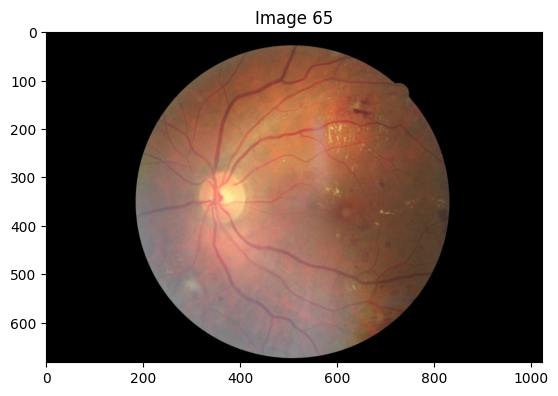

In [8]:
def imshow(image, title_str):
    if len(image.shape) > 2:
        plt.imshow(image)
    else:
        plt.imshow(image, cmap=plt.cm.gray)
    plt.title(title_str)

plt.figure()
imshow(io.imread(os.path.join(DATA_ROOT, 'images', img_id + '.jpg')), 'Image %d' % n)
plt.show()

### Class Dataset

The class `` torch.utils.data.Dataset`` is an abstract class that represents a dataset.

To create our custom dataset in PyTorch we must inherit from this class and overwrite the following methods:

- `` __len__`` so that `` len (dataset) `` returns the size of the dataset.
- `` __getitem__`` to support indexing `` dataset [i] `` when referring to sample $i$

We are going to create the train and test datasets of our diagnostic problem. We will read the csv in the initialization method `` __init__`` but we will leave the explicit reading of the images for the method
`` __getitem__``. This approach is more efficient in memory because all the images are not loaded in memory at first, but are read individually when necessary.

Our dataset, through the method __getitem__, is going to provide samples encoded as a dictionary `` {'image': image, 'eye': eye, 'label': label} ``. Let us note that label is binary, computed from the original levels of the disease:  0-no DR, 1-DR. You can also take an optional `` transform '' argument so that we can add pre-processing and data augmentation techniques.



In [9]:
class RetinopathyDataset(Dataset):
    """Retinopathy dataset."""

    def __init__(self, csv_file, root_dir,transform=None,  maxSize=0):
        """
        Args:
            csv_file (string): Path al fichero csv con las anotaciones.
            root_dir (string): Directorio raÃ­z donde encontraremos la carpeta 'images'
            transform (callable, optional): Transformaciones opcionales a realizar sobre las imÃ¡genes.
        """
        self.dataset = pd.read_csv(csv_file,header=0,dtype={'id': str, 'eye': int, 'label': int})

        if maxSize>0:
            newDatasetSize=maxSize #maxSize muestras
            idx=np.random.RandomState(seed=42).permutation(range(len(self.dataset)))
            reduced_dataset=self.dataset.iloc[idx[0:newDatasetSize]]
            self.dataset=reduced_dataset.reset_index(drop=True)

        self.root_dir = root_dir
        self.img_dir = os.path.join(root_dir,'images')
        self.transform = transform
        self.levels = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
        self.classes = ['No DR', 'DR']

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        #Read the imagen
        img_name = os.path.join(self.img_dir,self.dataset.id[idx] + '.jpg')
        image = io.imread(img_name)
        #If the image is from right eye, we mirror it
        if self.dataset.eye[idx]==1:
            image=image[:,::-1,:]
        sample = {'image': image, 'eye' : self.dataset.eye[idx], 'label':  (self.dataset.label[idx]>0).astype(dtype=np.int64)}
        if self.transform:
            sample = self.transform(sample)
        return sample

We now instantiate the class to iterate over some samples to see what we generate.


0 (678, 1024, 3) 0
1 (678, 1024, 3) 0
2 (682, 1024, 3) 1
3 (682, 1024, 3) 0


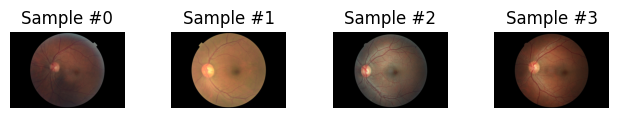

In [10]:
train_dataset = RetinopathyDataset(
    csv_file=os.path.join(DATA_ROOT, 'train.csv'),
    root_dir=DATA_ROOT)

fig = plt.figure()
for i in range(len(train_dataset)):
    sample = train_dataset[i]
    print(i, sample['image'].shape, sample['label'])
    ax = plt.subplot(1, 4, i + 1)
    plt.tight_layout()
    ax.set_title('Sample #{}'.format(i))
    ax.axis('off')
    plt.imshow(sample['image'])
    if i == 3:
        plt.show()
        break

**IMPORTANT**

The optional parameter ``maxSize`` in the constructor allows us to subsample the number of images and consequently reduce the size of the dataset. If not set included or maxSize=0, then the dataset will include all the images. This parameter is useful to train models over smaller datasets during hyperparameter validation and design phases. Working with less images reduces the training time at the expense of obtaining results that may deviate from those obtained with the full dataset size. Of course, the larger the training dataset, the more stable results but the larger the training time. Hence, it is up to the students the use of this parameter.

# Data pre-processing and Augmentation: Transforms


----------

In the previously shown examples we can see that the size of the images is not the same. This would prevent to train a convolutional neuronal network, as the vast majority require fixed-size inputs. Furthermore, the image is not always adjusted to the eye, and indeed, in some examples the eyes are small compared to the size of the image, whereas in others they spread along the full image dimensions. It would then be desirable to adjust the input images so that the eye covers almost the entire image.

To do this, we are going to create some preprocessing code, focusing on 5 transformations:
- ``CropByEye``: to crop the eye part of the image and remove surrounding black areas.
- ``Rescale``: to scale the image
- ``RandomCrop``: to crop the image randomly around the image center, it allows us to augment the data samples with random crops
- ``CenterCrop``: to perform a central crop of the image with the indicated size (useful in test)
- ``ToTensor``: to convert numpy matrices into torch tensors (rearranging the axes).

We will define them as callable classes instead of simple functions, as we will not need to pass the transform  parameters every time we call a method. To do this, we only have to implement the `` __call__`` method and, if necessary, the `` __init__`` method.
Then we can use a transformation with the following code:

::

    tsfm = Transform(params)
    transformed_sample = tsfm(sample)


In [11]:
class CropByEye(object):
    """Crop the image using around the eye.

    Args:
        - TH: threshold to segment the eye (values between 0 - black and 1 - white).
        - border (tuple or int): Border surrounding the mask of the eye. We dilate the mask as the contrast between
        the eye and the background might be important.
        If it is a tuple, then it is (bordery,borderx)
    """

    def __init__(self, threshold, border):
        self.threshold = threshold
        assert isinstance(border, (int, tuple))
        if isinstance(border, int):
            self.border = (border,border)
        else:
            self.border = border

    def __call__(self, sample):
        image, eye, label = sample['image'], sample['eye'],sample['label']
        h, w = image.shape[:2]
        imgray = color.rgb2gray(image)
        #Compute the mask
        th, mask = cv2.threshold(imgray, self.threshold, 1, cv2.THRESH_BINARY)
        #Compute the coordinates of the bounding box that contains the mask
        sidx=np.nonzero(mask)
        #In case the mask is too small, impies malfunctioning
        if len(sidx[0])<20:
            return {'image': image, 'eye': eye, 'label' : label}
        minx=np.maximum(sidx[1].min()-self.border[1],0)
        maxx=np.minimum(sidx[1].max()+1+self.border[1],w)
        miny=np.maximum(sidx[0].min()-self.border[0],0)
        maxy=np.minimum(sidx[0].max()+1+self.border[1],h)
        #Crop the image
        image=image[miny:maxy,minx:maxx,...]


        return {'image': image, 'eye': eye, 'label' : label}
class Rescale(object):
    """Re-scale image to a predefined size.

    Args:
        output_size (tuple or int): The desired size. If it is a tuple, output is the output_size.
        If it is an int, the smallest dimension will be the output_size
            a we will keep fixed the original aspect ratio.
    """

    def __init__(self, output_size):
        assert isinstance(output_size, (int, tuple))
        self.output_size = output_size

    def __call__(self, sample):
        image, eye, label = sample['image'], sample['eye'],sample['label']

        h, w = image.shape[:2]
        if isinstance(self.output_size, int):
            if h > w:
                new_h, new_w = self.output_size * h / w, self.output_size
            else:
                new_h, new_w = self.output_size, self.output_size * w / h
        else:
            new_h, new_w = self.output_size

        new_h, new_w = int(new_h), int(new_w)

        image = transform.resize(image, (new_h, new_w))

        return {'image': image, 'eye': eye, 'label' : label}

class RandomCrop(object):
    """Randomly crop the image.

    Args:
        output_size (tuple or int): Crop size. If  int, square crop

    """

    def __init__(self, output_size):
        assert isinstance(output_size, (int, tuple))
        if isinstance(output_size, int):
            self.output_size = (output_size, output_size)
        else:
            assert len(output_size) == 2
            self.output_size = output_size

    def __call__(self, sample):
        image, eye, label = sample['image'], sample['eye'],sample['label']

        h, w = image.shape[:2]
        new_h, new_w = self.output_size

        if h>new_h:
            top = np.random.randint(0, h - new_h)
        else:
            top=0

        if w>new_w:
            left = np.random.randint(0, w - new_w)
        else:
            left = 0

        image = image[top: top + new_h,
                     left: left + new_w]


        return {'image': image, 'eye': eye, 'label': label}

class CenterCrop(object):
    """Crop the central area of the image

    Args:
        output_size (tupla or int): Crop size. If int, square crop

    """

    def __init__(self, output_size):
        assert isinstance(output_size, (int, tuple))
        if isinstance(output_size, int):
            self.output_size = (output_size, output_size)
        else:
            assert len(output_size) == 2
            self.output_size = output_size

    def __call__(self, sample):
        image, eye, label = sample['image'], sample['eye'],sample['label']
        h, w = image.shape[:2]
        new_h, new_w = self.output_size
        rem_h = h - new_h
        rem_w = w - new_w

        if h>new_h:
            top = int(rem_h/2)
        else:
            top=0

        if w>new_w:
            left = int(rem_w/2)
        else:
            left = 0

        image = image[top: top + new_h,
                     left: left + new_w]


        return {'image': image, 'eye': eye, 'label': label}


class ToTensor(object):
    """Convert ndarrays into PyTorch tensors."""

    def __call__(self, sample):
        image, eye, label = sample['image'], sample['eye'],sample['label']

        # Cambiamos los ejes
        # numpy image: H x W x C
        # torch image: C X H X W
        image = image.transpose((2, 0, 1))
        image = torch.from_numpy(image)
        label=torch.tensor(label,dtype=torch.long)

        return {'image':image,
                'eye':eye,
                'label':label}

class Normalize(object):
    """Normalize data by subtracting means and dividing by standard deviations.

    Args:
        mean_vec: Vector with means.
        std_vec: Vector with standard deviations.
    """

    def __init__(self, mean,std):

        assert len(mean)==len(std),'Length of mean and std vectors is not the same'
        self.mean = np.array(mean)
        self.std = np.array(std)

    def __call__(self, sample):
        image, eye, label = sample['image'], sample['eye'],sample['label']
        c, h, w = image.shape
        assert c==len(self.mean), 'Length of mean and image is not the same'
        dtype = image.dtype
        mean = torch.as_tensor(self.mean, dtype=dtype, device=image.device)
        std = torch.as_tensor(self.std, dtype=dtype, device=image.device)
        image.sub_(mean[:, None, None]).div_(std[:, None, None])


        return {'image': image, 'eye': eye, 'label' : label}

### Exercise:

Use the following code to apply the previous transforms and experiment with the values of the parameters to study their influence. Read the documentation at the begining of each class to understand the sintaxis of the input parameters.



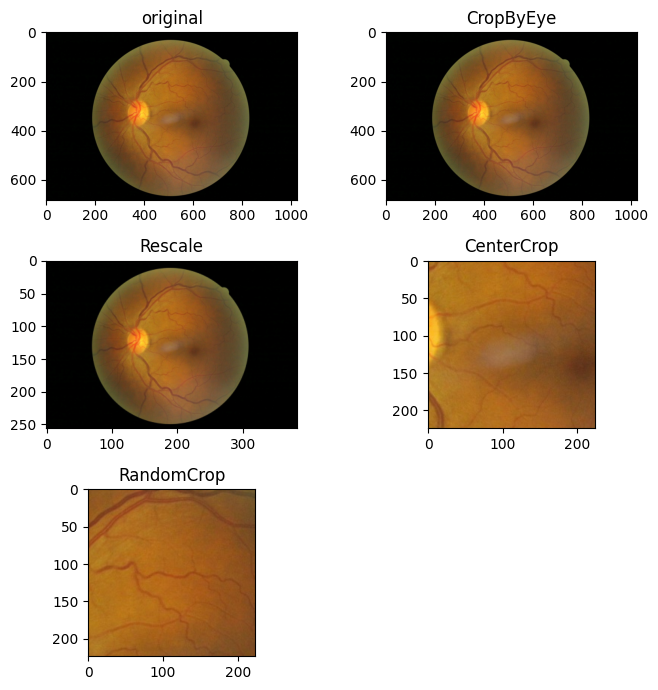

In [12]:
### Modify this code to make your experiments....
cropByEye = CropByEye(threshold=0.00,border=0)
scale = Rescale(256)
rcrop = RandomCrop(224)
ccrop = CenterCrop(224)

# Apply each of the above transforms on sample.
fig = plt.figure(figsize=(7,7))
sample = train_dataset[4]
ax = plt.subplot(3,2, 1)
plt.tight_layout()
ax.set_title('original')
plt.imshow(sample['image'])

for i, tsfrm in enumerate([cropByEye,scale, ccrop, rcrop]):
    transformed_sample = tsfrm(sample)

    ax = plt.subplot(3, 2, i+2)
    plt.tight_layout()
    ax.set_title(type(tsfrm).__name__)
    plt.imshow(transformed_sample['image'])

plt.show()

#### Using package torchvision.transforms

Package torchvision.trasforms comes with many useful methods that implement valuable transforms for data augmentation. Those transforms can be applied either to torch.tensors or to images. However, torchvision uses PIL library to read and process images, in contrast to the matrix representation of images used in scikit-image library (the library we have used in the previous methods). Hence, in order to use a torchvision transform we need to implement a pipeline that:

- 1) First, convert the matrix-based images to PILImages
- 2) Apply the transform to PILImages
- 3) Convert PILImages to matrices

And applies these to input images. The following class ``TVCenterCrop`` implements the same functionality as the previous ``CenterCrop``, but using the corresponding method in torchvision. It is therefore a useful example if you plan to make use of torchvision transforms.


In [13]:
class TVCenterCrop(object):
    """Crop the central area of the image. Example using the method in torchvision. Requires to
    internally convert from skimage (numpy array) to PIL Image

    Args:
        output_size (tupla or int): Crop size. If int, square crop

    """

    def __init__(self, size):
        self.CC=transforms.CenterCrop(size)

    def __call__(self, sample):
        image, eye, label = sample['image'], sample['eye'],sample['label']
        pil_image=Image.fromarray(util.img_as_ubyte(image))
        pil_image=self.CC(pil_image)
        image=util.img_as_float(np.asarray(pil_image))

        return {'image': image, 'eye': eye, 'label': label}

Now, we apply to transform to check the results

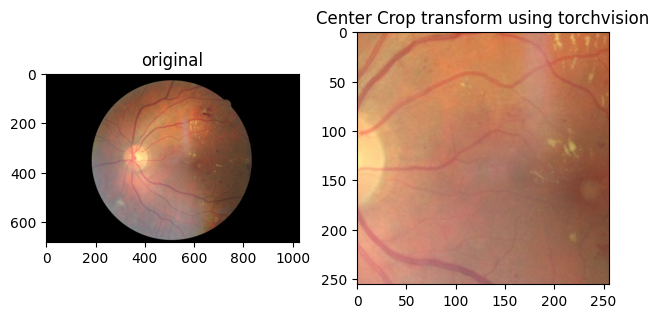

In [ ]:
# Apply each of the above transforms on sample.
fig = plt.figure()
sample = train_dataset[65]
ax = plt.subplot(1,2, 1)
plt.tight_layout()
ax.set_title('original')
plt.imshow(sample['image'])

tvcc=TVCenterCrop(256)

transformed_sample = tvcc(sample)
ax = plt.subplot(1, 2, 2)
plt.tight_layout()
ax.set_title('Center Crop transform using torchvision')
plt.imshow(transformed_sample['image'])

plt.show()

### Exercise

Implement other transforms using torchvision package. Take TVCenterCrop as guide.


In [14]:
class TVRandomHorizontalFlip(object):
    """Random horizontal flip using torchvision.
    Justified: fundus images from left/right eyes are mirror-symmetric;
    horizontal flip simulates this real-world variation.
    Args:
        p (float): probability of flip (default 0.5)
    """
    def __init__(self, p=0.5):
        self.flip = transforms.RandomHorizontalFlip(p=p)

    def __call__(self, sample):
        image, eye, label = sample['image'], sample['eye'], sample['label']
        pil_image = Image.fromarray(util.img_as_ubyte(image))
        pil_image = self.flip(pil_image)
        image = util.img_as_float(np.asarray(pil_image))
        return {'image': image, 'eye': eye, 'label': label}


class TVRandomRotation(object):
    """Random rotation using torchvision.
    Justified: fundus cameras are sometimes slightly tilted;
    small rotations (+-15 deg) simulate real-world acquisition variation.
    Args:
        degrees (int): max rotation angle in both directions
    """
    def __init__(self, degrees=15):
        self.rotate = transforms.RandomRotation(degrees=degrees)

    def __call__(self, sample):
        image, eye, label = sample['image'], sample['eye'], sample['label']
        pil_image = Image.fromarray(util.img_as_ubyte(image))
        pil_image = self.rotate(pil_image)
        image = util.img_as_float(np.asarray(pil_image))
        return {'image': image, 'eye': eye, 'label': label}


class TVColorJitter(object):
    """Random colour jitter using torchvision.
    Justified: fundus cameras across clinical sites differ in exposure,
    lighting, and calibration; colour jitter simulates these variations.
    Args:
        brightness, contrast, saturation, hue: jitter ranges
    """
    def __init__(self, brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05):
        self.jitter = transforms.ColorJitter(
            brightness=brightness, contrast=contrast,
            saturation=saturation, hue=hue)

    def __call__(self, sample):
        image, eye, label = sample['image'], sample['eye'], sample['label']
        pil_image = Image.fromarray(util.img_as_ubyte(image))
        pil_image = self.jitter(pil_image)
        image = util.img_as_float(np.asarray(pil_image))
        return {'image': image, 'eye': eye, 'label': label}

### Composed Transforms

Now let's apply the different transformations to our images.

We will rescale the images so that their smallest dimension is 224 and then make random crops of size 224. To compose the transformations ``Rescale`` and ``RandomCrop`` we can use ``torchvision.transforms.Compose``, which is a simple callable class.


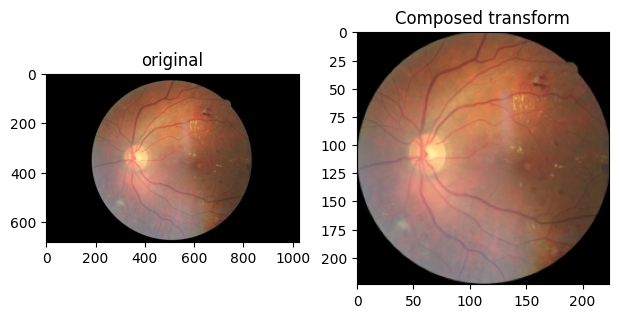

In [15]:
composed = transforms.Compose([CropByEye(0.10,1),Rescale(224),RandomCrop(224)])

# Apply each of the above transforms on sample.
fig = plt.figure()
sample = train_dataset[65]
ax = plt.subplot(1,2, 1)
plt.tight_layout()
ax.set_title('original')
plt.imshow(sample['image'])

transformed_sample = composed(sample)
ax = plt.subplot(1, 2, 2)
plt.tight_layout()
ax.set_title('Composed transform')
plt.imshow(transformed_sample['image'])

plt.show()

### Exercise:

Use the previous code to test different combinations of transform and discuss the results.

### Exercise:

Data augmentation techniques are useful as long as they model random transforms that may happen in the real world, and so can be found in test. Hence, the choice of the data augmentation techniques to be applied is problem-dependent and may differ from one dataset to another. Have a look at the images in the dataset and try to figure out which transforms are appropriate for these problem. Imagine how colorfundus images are taken and which factors may differ from one capture to another. Your results in the challenge will strongly depend on your design!!!!

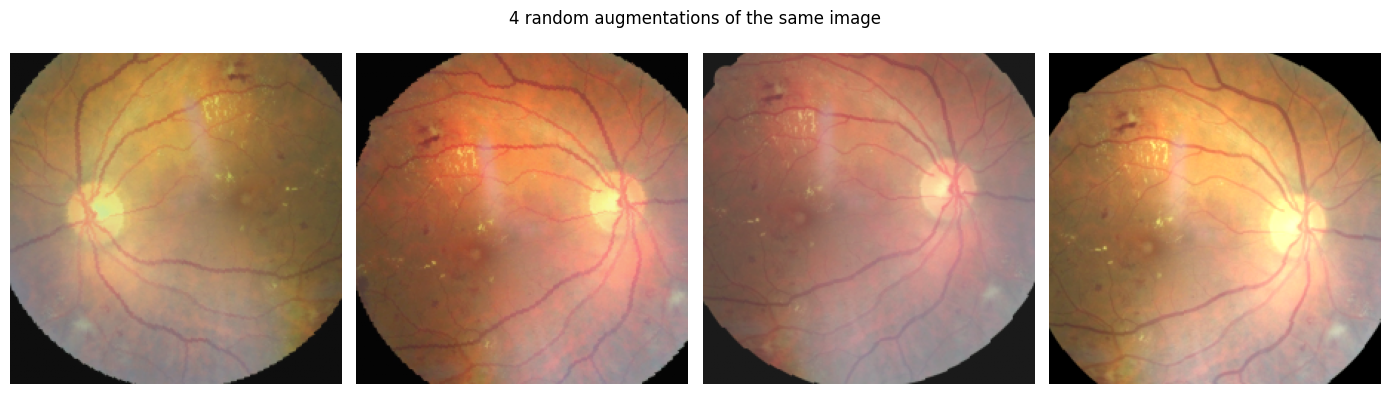

In [16]:
# Compose augmentation pipeline and visualise 4 stochastic variants of one image
augment_composed = transforms.Compose([
    CropByEye(0.10, 1),
    Rescale(256),
    TVRandomHorizontalFlip(p=0.5),   # simulates left/right eye symmetry
    TVRandomRotation(degrees=15),     # simulates camera tilt
    TVColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    RandomCrop(224),
])

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
sample = train_dataset[65]
for ax in axes:
    aug_sample = augment_composed(sample)
    ax.imshow(aug_sample['image'])
    ax.axis('off')
fig.suptitle('4 random augmentations of the same image')
plt.tight_layout()
plt.show()

Iterating the dataset
-----------------------------

We can now put everything together to create the train and test datasets with the corresponding transformations.
In summary, every time we sample an image from the dataset (during training):
- We will read the image
- We will apply the transformations and we will crop the image using a bounding box indicating the eye area, which is automatically computed from the input image by thresholding.
- As the final cropping operation is random, we perform data augmentation during sampling

We can easily iterate over the dataset with a ``for i in range`` loop.


In [17]:
#Pixel means and stds expected by models in torchvision
pixel_mean = [0.485, 0.456, 0.406]
pixel_std  = [0.229, 0.224, 0.225]

# Training transform: includes augmentation (flip, rotation, colour jitter)
train_transform = transforms.Compose([
    CropByEye(0.10, 1),
    Rescale(256),
    TVRandomHorizontalFlip(p=0.5),
    TVRandomRotation(degrees=15),
    TVColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    RandomCrop(224),
    ToTensor(),
    Normalize(mean=pixel_mean, std=pixel_std),
])

# Val/test transform: deterministic, no augmentation
eval_transform = transforms.Compose([
    CropByEye(0.10, 1),
    Rescale(224),
    CenterCrop(224),
    ToTensor(),
    Normalize(mean=pixel_mean, std=pixel_std),
])

# maxSize=0 uses all 2000 training images; set to e.g. 500 for quick experiments
train_dataset = RetinopathyDataset(
    csv_file=os.path.join(DATA_ROOT, 'train.csv'),
    root_dir=DATA_ROOT,
    maxSize=0,
    transform=train_transform)

val_dataset = RetinopathyDataset(
    csv_file=os.path.join(DATA_ROOT, 'val.csv'),
    root_dir=DATA_ROOT,
    transform=eval_transform)

test_dataset = RetinopathyDataset(
    csv_file=os.path.join(DATA_ROOT, 'test.csv'),
    root_dir=DATA_ROOT,
    transform=eval_transform)

for i in range(4):
    sample = train_dataset[i]
    print(i, sample['image'].size(), sample['label'])

0 torch.Size([3, 224, 224]) tensor(0)
1 torch.Size([3, 224, 224]) tensor(0)
2 torch.Size([3, 224, 224]) tensor(1)
3 torch.Size([3, 224, 224]) tensor(0)


Finally, we have to create a dataloader allowing to:

- Sample batches of samples to feed the network during training
- Shuffle data
- Load the data in parallel using multiple cores.

``torch.utils.data.DataLoader`` is an iterator that provides all these features. An important parameter of the iterator is ``collate_fn``. We can specify how samples are organized in batches by choosing the most appropriate function. In any case, the default option should work fine in most cases.




0 torch.Size([64, 3, 224, 224]) tensor([1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
        1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
        1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1])


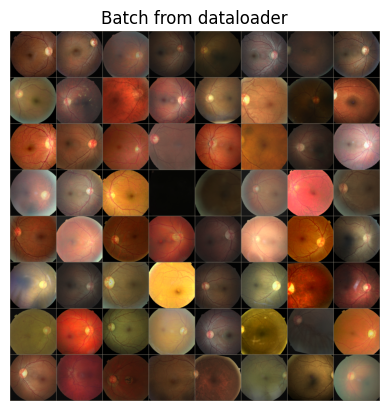

KeyboardInterrupt: 

In [18]:
# num_workers=0 required on Windows (PyTorch multiprocessing bug)
train_dataloader = DataLoader(train_dataset, batch_size=64,
                               shuffle=True, num_workers=0)
val_dataloader   = DataLoader(val_dataset,   batch_size=256,
                               shuffle=False, num_workers=0)
test_dataloader  = DataLoader(test_dataset,  batch_size=256,
                               shuffle=False, num_workers=0)

def show_batch(sample_batched):
    images_batch = sample_batched['image']
    grid = utils.make_grid(images_batch).numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    grid = np.clip(std * grid + mean, 0, 1)
    plt.imshow(grid)
    plt.title('Batch from dataloader')

for i_batch, sample_batched in enumerate(train_dataloader):
    print(i_batch, sample_batched['image'].size(), sample_batched['label'])
    plt.figure()
    show_batch(sample_batched)
    plt.axis('off')
    plt.ioff()
    plt.show()
    if i_batch == 3:
        break

# OLD

## Part 2: Design and train a custom diagnosis network -- OLD
In the second part of the practice we are designing a diagnosis network from scratch. For that end, we next provide a definition of a network which is very similar to LeNet-5, which aims to classifiy input images of size 32x32 px containing digits (MNIST dataset with 10 classes). However, in this case, we are not forced to work with such small images and, indeed, it is highly recommended to user larger sizes (e.g. 224x224 px as it represents the standard size for most well-known networks trained in Imagenet).

In the following cell we provide the skeleton of a network called CustomNet, with the necessary methods: ` __init__` (constructor) and ``forward`` (forward method processes an image and predicts DR presence, providing a probabilistic value at the output).


In [ ]:
# class CustomNet(nn.Module):
#     """
#     CNN for binary DR classification.
#     Input:  N x 3 x 224 x 224
#     Output: N x 1  (raw logit; sigmoid applied by loss / test_model)

#     Spatial progression (Conv5 no-pad -> MaxPool2):
#       224 -> 220 -> 110  (conv1 + pool)
#       110 -> 106 ->  53  (conv2 + pool)
#        53 ->  49 ->  24  (conv3 + pool)
#        24 ->  20 ->  10  (conv4 + pool)
#     Flattened: 64 * 10 * 10 = 6400
#     """
#     def __init__(self):
#         super(CustomNet, self).__init__()
#         self.conv1   = nn.Conv2d(3, 6, 5)
#         self.bn1     = nn.BatchNorm2d(6)
#         self.pool    = nn.MaxPool2d(2, 2)
#         self.conv2   = nn.Conv2d(6, 16, 5)
#         self.bn2     = nn.BatchNorm2d(16)
#         self.conv3   = nn.Conv2d(16, 32, 5)
#         self.bn3     = nn.BatchNorm2d(32)
#         self.conv4   = nn.Conv2d(32, 64, 5)
#         self.bn4     = nn.BatchNorm2d(64)
#         self.fc1     = nn.Linear(64 * 10 * 10, 120)
#         self.fc2     = nn.Linear(120, 84)
#         self.dropout = nn.Dropout(0.5)
#         self.fc3     = nn.Linear(84, 1)

#     def forward(self, x):
#         x = self.pool(F.relu(self.bn1(self.conv1(x))))
#         x = self.pool(F.relu(self.bn2(self.conv2(x))))
#         x = self.pool(F.relu(self.bn3(self.conv3(x))))
#         x = self.pool(F.relu(self.bn4(self.conv4(x))))
#         x = x.flatten(1)
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
#         x = self.dropout(x)
#         x = self.fc3(x)
#         return x

#### Exercise:

Modify the previous code and define a CNN that processes a batch of images (e.g. of size 224x224) and computes their outputs providing a scores for predicting DR.

**IMPORTANT**: The structure of the network must be consistent in order to transform the input tensor  Nx3x224x224 (N the number of images in the batch, 3 the RGB channels, and 224 the spatial dimensions) into the tensor with the scores of each case, with size Nx1 (N the number of images in the batch and 1 the probability of DR). To do so, you have to adjust the architecture of the previous example, including the number of layers, the strides of each one, etc. so that it transforms the input tensor into the desired final vector. As an aid, the following code is provided that allows you to run the grid over a batch of images and see what the is shape of the output.

In [ ]:
# customNet = CustomNet() #we initialize the network
# customNet.to(device) #copy the network to the device (gpu)
# #Sample a batch of data and get images and labels
# data=next(iter(train_dataloader))
# inputs = data['image'].to(device).float()
# labels = data['label'].to(device)

# batchSize = labels.shape
# print('Size of tensor containing a batch of images is {}'.format(inputs.shape))

# #Lo pasamos por la red
# with torch.set_grad_enabled(False):
#     outputs = customNet(inputs)
#     print('Size of the output tensor is {}'.format(outputs.shape))



**Hint**: Start commenting all lines in the forward method in except of the first convolutional layer, execute the previous cell and and you will see the shape of the output of that layer. Go uncommenting layer by layer to see the sequential output sizes to decide how many convolutional layers may be adequate and the dimensions of the first fully convolutional layer.

## Part 3: Train and evaluate our CNN -- OLD

In the third part of the practice we are going to build a first automatic system for the diagnosis of Diabetic Retinopathy based on the network that we have created in the previous section. To train and evaluate the network, we need to define several elements, such as the performance metric, the loss function, the optimizer or the learning rate strategy. In the next sections we will configure these elements.

### Performance Metric for evaluation
We will start by defining the metric we will use to evaluate our network. In particular, we will use the area under the ROC or AUC (https://en.wikipedia.org/wiki/Receiver_operating_characteristic#Area_under_the_curve).

AUC is a metric that avoids setting a specific threshold to make detections and is applied over the soft outputs of a **binary** classifier. By modifying the value of the threshold, we can build a ROC curve setting the False Positive Rate (FPR) in the y-axis and the True Positive Rate (TPR) in the x-axis. TPR is the proportion of positive cases than have been succesfully detected, whereas FPR is the number of false detections divided by the number of negatives.

For low detection thresholds and an imperfect system, TPR will be high at the expense of a high FPR (as the system always says 1). For high threholds, the opposite situation happens. Once the ROC is built, the AUC measures the integral behind the curve, which is in the range [0,1].

Although, at least theoretically, AUC can be lower than 0.5, in pratice, the output of a baseline system that randomly decides 0 or 1 with equal probability obtains an AUC=0.5, so lower values are usually caused by bugs in the code (and could be avoided just by inverting the outputs of the system).

The following figure shows some examples of AUC and ROC curves:

<center><img src='https://upload.wikimedia.org/wikipedia/commons/thumb/1/13/Roc_curve.svg/1024px-Roc_curve.svg.png' width=384 /></center>

As we have mentioned, AUC is a metric to evaluate binary problems (labels 0,1), and has the advantage of being independent of the detection threshold. It also behaves well against unbalanced problems, as it evaluates the ranking of the scores (their order with respect to the labels) and not their absolute values.

Since our problem is binary (DR vs no DR), we will use AUC to assess the performance, with the following method from scikit-learn:

> auc = metrics.roc_auc_score(labels, scores)


### Loss function, optimizer, and learning rate strategy

In the next cell we will define the 3 elements we need to train:
- The loss function, which will be a crossed entropy. Using the loss BCEWithLogitsLoss(), we implement a sigmoid to obtain the p(y=1|x) followed by a Binary Cross-Entropy (BCE) loss.
- The optimizer, in which we will use a SGD with momentum, with certain values of lr and momentum
- A learning rate strategy, using a fixed step method, decreasing the lr by a factor of 10, every 7 epochs.


In [ ]:
# customNet = CustomNet()
# customNet.to(device)

# # Class-weighted loss to handle 73%/27% No-DR/DR imbalance.
# # pos_weight = n_neg / n_pos penalises missed DR cases more heavily.
# train_labels_bin = (train_dataset.dataset['label'].values > 0).astype(int)
# n_neg = int((train_labels_bin == 0).sum())
# n_pos = int((train_labels_bin == 1).sum())
# pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float).to(device)
# print(f'Class distribution: {n_neg} No-DR, {n_pos} DR  =>  pos_weight={pos_weight.item():.2f}')

# # BCEWithLogitsLoss: numerically stable sigmoid+BCE in one op.
# # network forward() must return raw logits (no sigmoid at the end).
# criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# optimizer_ft    = optim.SGD(customNet.parameters(), lr=1e-2, momentum=0.9)
# exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=10, gamma=0.1)

### Training function

We continue by defining the function that we will use to train our classifier. Note the existence of 3 nested loops:
- Epoch loop: a main loop that goes through training epochs and then allows values to be taken from the evaluation metrics.
- Database loop: the train database is executed first, training the model, and then the validation database, only to obtain outputs and calculate evaluation metrics.
- Loop of iterations: in each iteration the forward, the evaluation of the loss, the backward and the updating of the weights in the optimizer are made.

In [ ]:
# def train_model(model, criterion, optimizer, scheduler, num_epochs=25, patience=7):
#     since = time.time()
#     best_model_wts = copy.deepcopy(model.state_dict())
#     best_auc   = 0.0
#     best_epoch = -1
#     no_improve = 0  # epochs without val-AUC improvement

#     for epoch in range(num_epochs):
#         print('Epoch {}/{}'.format(epoch, num_epochs - 1))
#         print('-' * 10)

#         for phase in ['train', 'val']:
#             model.train() if phase == 'train' else model.eval()

#             numSamples   = dataset_sizes[phase]
#             outputs_m    = np.zeros((numSamples,), dtype=float)
#             labels_m     = np.zeros((numSamples,), dtype=int)
#             running_loss = 0.0
#             contSamples  = 0

#             for sample in dataloaders[phase]:
#                 inputs = sample['image'].to(device).float()
#                 labels = sample['label'].to(device).float()
#                 batchSize = labels.shape[0]
#                 optimizer.zero_grad()

#                 with torch.set_grad_enabled(phase == 'train'):
#                     logits = model(inputs).flatten()
#                     # BCEWithLogitsLoss takes raw logits (sigmoid is internal)
#                     loss   = criterion(logits, labels)
#                     # Sigmoid applied separately to store probability scores for AUC
#                     scores = torch.sigmoid(logits).detach()
#                     if phase == 'train':
#                         loss.backward()
#                         optimizer.step()

#                 running_loss += loss.item() * batchSize
#                 outputs_m[contSamples:contSamples + batchSize] = scores.cpu().numpy()
#                 labels_m [contSamples:contSamples + batchSize] = labels.cpu().numpy()
#                 contSamples += batchSize

#             if phase == 'train':
#                 scheduler.step()

#             epoch_loss = running_loss / dataset_sizes[phase]
#             epoch_auc  = metrics.roc_auc_score(labels_m, outputs_m)
#             print('{} Loss: {:.4f}  AUC: {:.4f}'.format(phase, epoch_loss, epoch_auc))

#             if phase == 'val':
#                 if epoch_auc > best_auc:
#                     best_auc        = epoch_auc
#                     best_epoch      = epoch
#                     best_model_wts  = copy.deepcopy(model.state_dict())
#                     no_improve      = 0
#                 else:
#                     no_improve += 1
#                     if no_improve >= patience:
#                         print(f'Early stopping: no val-AUC improvement for {patience} epochs.')
#                         model.load_state_dict(best_model_wts)
#                         return model
#         print()

#     elapsed = time.time() - since
#     print('Training complete in {:.0f}m {:.0f}s'.format(elapsed // 60, elapsed % 60))
#     print('Best model: epoch {:d}  val AUC: {:.4f}'.format(best_epoch, best_auc))
#     model.load_state_dict(best_model_wts)
#     return model

### Specifying the data loaders
Now we are going to assign the dataloaders that we had previously to the arrays of train and val

In [ ]:
image_datasets = {'train' : train_dataset, 'val': val_dataset}

dataloaders = {'train' : train_dataloader, 'val': val_dataloader}

dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}
class_names = image_datasets['train'].classes


### Train your custom network
Finally, we can train the network for several epochs and see the train and validation results.

In [ ]:
# random.seed(42)
# npr.seed(42)
# torch.manual_seed(42)
# torch.cuda.manual_seed_all(42)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

# customNet = train_model(customNet, criterion, optimizer_ft, exp_lr_scheduler,
#                         num_epochs=30, patience=7)

#### Exercise:

The current code trains the network for 10 epochs using SGD with momentum, with a learning rate strategy and an early stop strategy (taking the epoch that obtains the best results in validation). You can modify this setting by choosing other values for parameters, optimizers, strategies, etc.


#### Exercise

The current code trains the network for 10 epochs and then returns the model that obtains the best results in validation (measured through the AUC). It could be necessary, in case the training times are long and you work with Google Colab (with limits on the duration of the session), to implement a save-and-resume strategy that allows you to train models through different sessions . You can find details on how to do it at:

https://pytorch.org/tutorials/recipes/recipes/saving_and_loading_a_general_checkpoint.html

# Functions

In [19]:
import os, json, copy, time
import numpy as np
from sklearn import metrics
import torch

def train_model(model, criterion, optimizer, scheduler,
                num_epochs=25, patience=7,
                checkpoint_dir='checkpoints',
                run_name='model'):
    """
    Args:
        checkpoint_dir : folder where checkpoints are written
        run_name       : prefix for checkpoint filenames
                         e.g. 'customNet' or 'ftNet'

    Returns:
        model   : best model (weights loaded automatically)
        history : dict with keys 'train_loss', 'val_loss',
                  'train_auc', 'val_auc'  (one value per epoch)
    """
    os.makedirs(checkpoint_dir, exist_ok=True)

    history = {'train_loss': [], 'val_loss': [],
               'train_auc':  [], 'val_auc':  []}

    best_model_wts = copy.deepcopy(model.state_dict())
    best_auc       = 0.0
    best_epoch     = -1
    no_improve     = 0
    start_epoch    = 0

    # ── Resume from last checkpoint if one exists ────────────────────────────
    last_ckpt = os.path.join(checkpoint_dir, f'{run_name}_last.pt')
    hist_path = os.path.join(checkpoint_dir, f'{run_name}_history.json')

    if os.path.exists(last_ckpt):
        print(f'[resume] Loading checkpoint: {last_ckpt}')
        ckpt = torch.load(last_ckpt, map_location=device)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        start_epoch = ckpt['epoch'] + 1
        best_auc    = ckpt['best_auc']
        no_improve  = ckpt['no_improve']
        best_model_wts = ckpt['best_model_wts']
        if os.path.exists(hist_path):
            with open(hist_path) as f:
                history = json.load(f)
        print(f'[resume] Continuing from epoch {start_epoch}  '
              f'(best val AUC so far: {best_auc:.4f})')
    else:
        print(f'[train] Starting fresh — checkpoints → {checkpoint_dir}/{run_name}_*.pt')

    since = time.time()

    for epoch in range(start_epoch, num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            numSamples   = dataset_sizes[phase]
            outputs_m    = np.zeros((numSamples,), dtype=float)
            labels_m     = np.zeros((numSamples,), dtype=int)
            running_loss = 0.0
            contSamples  = 0

            for sample in dataloaders[phase]:
                inputs    = sample['image'].to(device).float()
                labels    = sample['label'].to(device).float()
                batchSize = labels.shape[0]
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    logits = model(inputs).flatten()
                    loss   = criterion(logits, labels)
                    scores = torch.sigmoid(logits).detach()
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * batchSize
                outputs_m[contSamples:contSamples + batchSize] = scores.cpu().numpy()
                labels_m [contSamples:contSamples + batchSize] = labels.cpu().numpy()
                contSamples += batchSize

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_auc  = metrics.roc_auc_score(labels_m, outputs_m)
            print(f'{phase:5s}  loss: {epoch_loss:.4f}  AUC: {epoch_auc:.4f}')

            # ── Record history ───────────────────────────────────────────────
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_auc'].append(epoch_auc)

            # ── Track best model ─────────────────────────────────────────────
            if phase == 'val':
                if epoch_auc > best_auc:
                    best_auc       = epoch_auc
                    best_epoch     = epoch
                    best_model_wts = copy.deepcopy(model.state_dict())
                    no_improve     = 0
                    # Save dedicated best-model file
                    best_path = os.path.join(checkpoint_dir, f'{run_name}_best.pt')
                    torch.save({'epoch': epoch,
                                'model_state': best_model_wts,
                                'val_auc': best_auc}, best_path)
                    print(f'  ✓ New best — saved to {best_path}')
                else:
                    no_improve += 1

        # ── Save end-of-epoch checkpoint (overwrites previous "last") ────────
        torch.save({
            'epoch':           epoch,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'best_auc':        best_auc,
            'best_model_wts':  best_model_wts,
            'no_improve':      no_improve,
        }, last_ckpt)

        # ── Save history alongside checkpoint ────────────────────────────────
        with open(hist_path, 'w') as f:
            json.dump(history, f, indent=2)

        # ── Early stopping ───────────────────────────────────────────────────
        if no_improve >= patience:
            print(f'Early stopping: no val-AUC improvement for {patience} epochs.')
            break

        print()

    elapsed = time.time() - since
    print(f'Training complete in {elapsed//60:.0f}m {elapsed%60:.0f}s')
    print(f'Best model: epoch {best_epoch}  val AUC: {best_auc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, history

In [20]:
# =============================================================================
# TRAINING CURVES
# =============================================================================

def plot_training_curves(history, title='Training curves'):
    """Plot loss and AUC curves from the history dict."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # ── Loss ─────────────────────────────────────────────────────────────────
    ax1.plot(epochs, history['train_loss'], label='Train', color='steelblue')
    ax1.plot(epochs, history['val_loss'],   label='Val',   color='coral')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('BCE Loss')
    ax1.set_title(f'{title} — Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ── AUC ──────────────────────────────────────────────────────────────────
    ax2.plot(epochs, history['train_auc'], label='Train', color='steelblue')
    ax2.plot(epochs, history['val_auc'],   label='Val',   color='coral')
    best_epoch = int(np.argmax(history['val_auc'])) + 1
    best_auc   = max(history['val_auc'])
    ax2.axvline(best_epoch, color='gray', linestyle='--', linewidth=1,
                label=f'Best epoch {best_epoch} (AUC={best_auc:.4f})')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('AUC')
    ax2.set_title(f'{title} — AUC')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150)
    plt.show()

# Preprocess and cache all images to disk once, then load the cached versions during training.

In [74]:
CACHE_DIR = '/content/cache_224'

In [ ]:
# # =============================================================================
# # STEP 1 — Run this cell ONCE to preprocess and cache all images to disk.
# # After this, training batches will load in < 1s instead of 57s.
# # =============================================================================

# import os
# import numpy as np
# from skimage import io, transform, color
# import cv2
# from tqdm import tqdm
# import pandas as pd

# DATA_ROOT  = '/content/drive/MyDrive/CV/data'
# OUTPUT_SIZE = 224            # final spatial size saved to disk

# os.makedirs(CACHE_DIR, exist_ok=True)

# def preprocess_image(img_path, eye, output_size=224,
#                      threshold=0.10, border=1):
#     """
#     Applies CropByEye + Rescale + CenterCrop and returns a float32
#     numpy array of shape (3, output_size, output_size) ready for training.
#     The heavy OpenCV/skimage ops happen here, once per image.
#     """
#     image = io.imread(img_path)

#     # Mirror right-eye images
#     if eye == 1:
#         image = image[:, ::-1, :]

#     # ── CropByEye ────────────────────────────────────────────────────────────
#     h, w   = image.shape[:2]
#     imgray = color.rgb2gray(image)
#     _, mask = cv2.threshold(imgray, threshold, 1, cv2.THRESH_BINARY)
#     sidx   = np.nonzero(mask)
#     if len(sidx[0]) >= 20:
#         minx = max(sidx[1].min() - border, 0)
#         maxx = min(sidx[1].max() + 1 + border, w)
#         miny = max(sidx[0].min() - border, 0)
#         maxy = min(sidx[0].max() + 1 + border, h)
#         image = image[miny:maxy, minx:maxx]

#     # ── Rescale (smallest dim → output_size) ─────────────────────────────────
#     h, w = image.shape[:2]
#     if h > w:
#         new_h, new_w = int(output_size * h / w), output_size
#     else:
#         new_h, new_w = output_size, int(output_size * w / h)
#     image = transform.resize(image, (new_h, new_w),
#                              anti_aliasing=True, preserve_range=False)

#     # ── CenterCrop ───────────────────────────────────────────────────────────
#     h, w   = image.shape[:2]
#     top    = max((h - output_size) // 2, 0)
#     left   = max((w - output_size) // 2, 0)
#     image  = image[top:top + output_size, left:left + output_size]

#     # ── Ensure exact shape (pad if image was smaller than output_size) ────────
#     if image.shape[0] != output_size or image.shape[1] != output_size:
#         pad_h = output_size - image.shape[0]
#         pad_w = output_size - image.shape[1]
#         image = np.pad(image,
#                        ((0, pad_h), (0, pad_w), (0, 0)),
#                        mode='constant')

#     # ── HWC float64 → CHW float32 ────────────────────────────────────────────
#     image = image.astype(np.float32).transpose(2, 0, 1)   # (3, H, W)
#     return image


# def cache_split(csv_file, split_name):
#     df = pd.read_csv(csv_file, header=0,
#                      dtype={'id': str, 'eye': int, 'label': int})
#     print(f'\nCaching {split_name} ({len(df)} images) → {CACHE_DIR}/')

#     for idx, row in tqdm(df.iterrows(), total=len(df)):
#         out_path = os.path.join(CACHE_DIR, f'{split_name}_{row["id"]}.npy')
#         if os.path.exists(out_path):
#             continue   # already cached — skip
#         img_path = os.path.join(DATA_ROOT, 'images', row['id'] + '.jpg')
#         arr = preprocess_image(img_path, row['eye'], OUTPUT_SIZE)
#         np.save(out_path, arr)

# cache_split(os.path.join(DATA_ROOT, 'train.csv'), 'train')
# cache_split(os.path.join(DATA_ROOT, 'val.csv'),   'val')
# cache_split(os.path.join(DATA_ROOT, 'test.csv'),  'test')

# print('\nDone. Cache size:',
#       sum(os.path.getsize(os.path.join(CACHE_DIR, f))
#           for f in os.listdir(CACHE_DIR)) // (1024**2), 'MB')

In [75]:
# =============================================================================
# STEP 2 — Lightweight Dataset that reads from cache instead of raw images.
# Replace RetinopathyDataset with this for training.
# The heavy CropByEye/Rescale/CenterCrop are already baked in.
# Only stochastic augmentation (flip, rotation, colour jitter) is applied
# at training time — these are fast torchvision ops on tensors.
# =============================================================================

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F

pixel_mean = [0.485, 0.456, 0.406]
pixel_std  = [0.229, 0.224, 0.225]

# Fast augmentation — applied to the cached (already cropped/resized) tensor
train_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05),
    transforms.Normalize(mean=pixel_mean, std=pixel_std),
])

eval_aug = transforms.Compose([
    transforms.Normalize(mean=pixel_mean, std=pixel_std),
])


class CachedRetinopathyDataset(Dataset):
    """
    Reads preprocessed .npy files from CACHE_DIR.
    Per-sample cost: one np.load + fast tensor augmentation.
    No OpenCV, no skimage, no JPEG decode at training time.
    """
    def __init__(self, csv_file, cache_dir, split_name,
                 augment=False, maxSize=0):
        self.df = pd.read_csv(csv_file, header=0,
                              dtype={'id': str, 'eye': int, 'label': int})
        if maxSize > 0:
            idx = np.random.RandomState(42).permutation(len(self.df))
            self.df = self.df.iloc[idx[:maxSize]].reset_index(drop=True)

        self.cache_dir   = cache_dir
        self.split_name  = split_name
        self.augment     = augment
        self.transform   = train_aug if augment else eval_aug
        self.classes     = ['No DR', 'DR']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        npy_path = os.path.join(self.cache_dir,
                                f'{self.split_name}_{row["id"]}.npy')
        image    = torch.from_numpy(np.load(npy_path))   # (3, 224, 224) float32
        label    = torch.tensor(int(row['label'] > 0), dtype=torch.long)
        image    = self.transform(image)
        return {'image': image, 'eye': int(row['eye']), 'label': label}

In [76]:
# =============================================================================
# STEP 3 — Rebuild datasets and dataloaders using the cache
# =============================================================================

train_dataset = CachedRetinopathyDataset(
    csv_file=os.path.join(DATA_ROOT, 'train.csv'),
    cache_dir=CACHE_DIR, split_name='train',
    augment=True, maxSize=0)

val_dataset = CachedRetinopathyDataset(
    csv_file=os.path.join(DATA_ROOT, 'val.csv'),
    cache_dir=CACHE_DIR, split_name='val',
    augment=False)

test_dataset = CachedRetinopathyDataset(
    csv_file=os.path.join(DATA_ROOT, 'test.csv'),
    cache_dir=CACHE_DIR, split_name='test',
    augment=False)

train_dataloader = DataLoader(train_dataset, batch_size=64,
                              shuffle=True,  num_workers=2, pin_memory=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=256,
                              shuffle=False, num_workers=2, pin_memory=True)
test_dataloader  = DataLoader(test_dataset,  batch_size=256,
                              shuffle=False, num_workers=2, pin_memory=True)

image_datasets = {'train': train_dataset, 'val': val_dataset}
dataloaders    = {'train': train_dataloader, 'val': val_dataloader}
dataset_sizes  = {'train': len(train_dataset), 'val': len(val_dataset)}

# ── Sanity check ─────────────────────────────────────────────────────────────
import time
t = time.time()
for i, batch in enumerate(train_dataloader):
    if i == 3:
        break
print(f'4 batches loaded in {time.time()-t:.1f}s')   # should be < 2s

4 batches loaded in 6.2s


In [77]:
!ls cache_224/

test_02500.npy	test_03375.npy	 train_00750.npy  train_01625.npy
test_02501.npy	test_03376.npy	 train_00751.npy  train_01626.npy
test_02502.npy	test_03377.npy	 train_00752.npy  train_01627.npy
test_02503.npy	test_03378.npy	 train_00753.npy  train_01628.npy
test_02504.npy	test_03379.npy	 train_00754.npy  train_01629.npy
test_02505.npy	test_03380.npy	 train_00755.npy  train_01630.npy
test_02506.npy	test_03381.npy	 train_00756.npy  train_01631.npy
test_02507.npy	test_03382.npy	 train_00757.npy  train_01632.npy
test_02508.npy	test_03383.npy	 train_00758.npy  train_01633.npy
test_02509.npy	test_03384.npy	 train_00759.npy  train_01634.npy
test_02510.npy	test_03385.npy	 train_00760.npy  train_01635.npy
test_02511.npy	test_03386.npy	 train_00761.npy  train_01636.npy
test_02512.npy	test_03387.npy	 train_00762.npy  train_01637.npy
test_02513.npy	test_03388.npy	 train_00763.npy  train_01638.npy
test_02514.npy	test_03389.npy	 train_00764.npy  train_01639.npy
test_02515.npy	test_03390.npy	 train_007

# PARTS 2 & 3 NEW

In [78]:
image_datasets = {'train' : train_dataset, 'val': val_dataset}

dataloaders = {'train' : train_dataloader, 'val': val_dataloader}

dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}
class_names = image_datasets['train'].classes

In [80]:
train_labels_bin = (train_dataset.df['label'].values > 0).astype(int)
# Class-weighted loss to handle 73%/27% No-DR/DR imbalance.
# pos_weight = n_neg / n_pos penalises missed DR cases more heavily.
n_neg = int((train_labels_bin == 0).sum())
n_pos = int((train_labels_bin == 1).sum())
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float).to(device)
print(f'Class distribution: {n_neg} No-DR, {n_pos} DR  =>  pos_weight={pos_weight.item():.2f}')

# BCEWithLogitsLoss: numerically stable sigmoid+BCE in one op.
# network forward() must return raw logits (no sigmoid at the end).
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


Class distribution: 1468 No-DR, 532 DR  =>  pos_weight=2.76


In [81]:
# Larger batch size → less noisy BatchNorm statistics
train_dataloader = DataLoader(train_dataset, batch_size=128,
                              shuffle=True, num_workers=2, pin_memory=True)

In [38]:
os.remove('checkpoints/customNet_last.pt')

FileNotFoundError: [Errno 2] No such file or directory: 'checkpoints/customNet_last.pt'

Total parameters    : 176,593
Trainable parameters: 176,593
Input shape  : torch.Size([4, 3, 224, 224])
Output shape : torch.Size([4, 1])
[train] Starting fresh — checkpoints → checkpoints/customNet_*.pt
Epoch 0/39
----------
train  loss: 1.1575  AUC: 0.5080
val    loss: 1.0312  AUC: 0.5418
  ✓ New best — saved to checkpoints/customNet_best.pt

Epoch 1/39
----------
train  loss: 1.1108  AUC: 0.4979
val    loss: 0.9879  AUC: 0.6035
  ✓ New best — saved to checkpoints/customNet_best.pt

Epoch 2/39
----------
train  loss: 1.0454  AUC: 0.5227
val    loss: 0.9828  AUC: 0.6145
  ✓ New best — saved to checkpoints/customNet_best.pt

Epoch 3/39
----------
train  loss: 1.0527  AUC: 0.5129
val    loss: 0.9989  AUC: 0.5895

Epoch 4/39
----------
train  loss: 1.0308  AUC: 0.5337
val    loss: 1.0231  AUC: 0.6018

Epoch 5/39
----------
train  loss: 1.0307  AUC: 0.5486
val    loss: 0.9816  AUC: 0.6332
  ✓ New best — saved to checkpoints/customNet_best.pt

Epoch 6/39
----------
train  loss: 1.0280  AUC

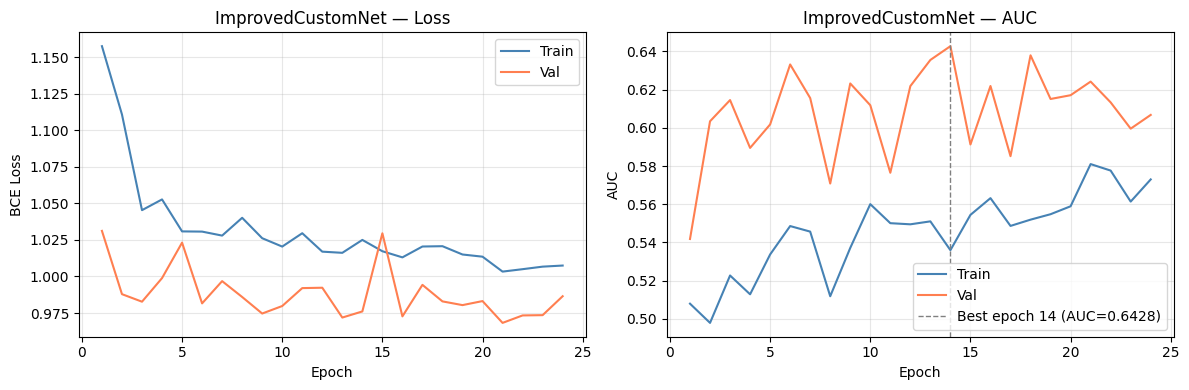

In [82]:
# =============================================================================
# IMPROVED CUSTOMNET — binary DR classification
# Architecture principles used:
#   1. 3×3 convolutions instead of 5×5  (more efficient, same receptive field)
#   2. Wider filter progression          (32 → 64 → 128 → 256)
#   3. Residual (skip) connections       (solves vanishing gradients)
#   4. BatchNorm before activation       (stabilises training)
#   5. Global Average Pooling            (replaces large FC layers)
# =============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


# ─────────────────────────────────────────────────────────────────────────────
# BUILDING BLOCK: ResidualBlock
# ─────────────────────────────────────────────────────────────────────────────
#
# A residual block applies two convolutions and then ADDS the input back to
# the result. This is the "skip connection":
#
#   input x
#     │
#     ├──► Conv → BN → ReLU → Conv → BN ──► + ──► ReLU ──► output
#     │                                      ▲
#     └──────────────────────────────────────┘  (skip connection)
#
# WHY THIS HELPS — vanishing gradients:
#   In a deep network, gradients flow backwards through every layer during
#   backprop. Each layer multiplies the gradient by its own weights, and if
#   those weights are small (< 1), the gradient shrinks exponentially as it
#   travels back — it "vanishes" before reaching the early layers, which
#   then learn nothing.
#
#   The skip connection gives the gradient a "shortcut" path that bypasses
#   the conv layers entirely. Even if the conv weights cause the gradient to
#   vanish along the main path, the gradient still flows strongly through
#   the shortcut. This lets us stack many more layers safely.
#
# WHY THIS HELPS — optimisation:
#   Instead of learning a mapping H(x), the block only needs to learn the
#   RESIDUAL F(x) = H(x) - x. If the ideal transformation is close to the
#   identity (i.e. "don't change x much"), the block just needs to learn
#   F(x) ≈ 0, which is much easier than learning H(x) ≈ x from scratch.
#
# PROJECTION SHORTCUT:
#   The skip connection requires input and output to have the SAME shape.
#   When we increase the number of filters (e.g. 32 → 64) or use stride > 1
#   to downsample, the shapes don't match. We fix this with a 1×1 convolution
#   on the skip path ("projection") that adjusts the number of channels and
#   spatial size to match the main path output.

class ResidualBlock(nn.Module):
    """
    Two-layer residual block with optional projection shortcut.

    Args:
        in_channels  : number of input feature maps
        out_channels : number of output feature maps
        stride       : stride of the first convolution.
                       stride=1 → same spatial size
                       stride=2 → halves spatial size (downsampling)
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        # ── Main path: two 3×3 convolutions ──────────────────────────────────
        #
        # WHY 3×3 instead of 5×5?
        #   Two stacked 3×3 convolutions see the same receptive field as one
        #   5×5 convolution (a 3×3 sees a 3×3 area; stacking two gives 5×5).
        #   But two 3×3s have FEWER parameters: 2×(3×3×C×C) = 18C² vs
        #   5×5×C×C = 25C². More importantly, there is a ReLU non-linearity
        #   between them, giving the network more representational power.
        #
        # padding=1 keeps spatial dimensions the same when stride=1
        # (input size - kernel + 2*padding) / stride + 1 = (H - 3 + 2) / 1 + 1 = H ✓

        self.conv1 = nn.Conv2d(in_channels,  out_channels,
                               kernel_size=3, stride=stride,
                               padding=1, bias=False)
        # WHY bias=False?
        #   BatchNorm (below) already has a learnable bias term (beta).
        #   Adding a conv bias on top is redundant — it would just be absorbed
        #   into BatchNorm's beta, wasting parameters.

        self.bn1   = nn.BatchNorm2d(out_channels)
        # WHY BatchNorm?
        #   Normalises the output of each conv layer to have mean≈0, std≈1.
        #   This prevents internal covariate shift — the phenomenon where the
        #   distribution of each layer's inputs changes as the weights of the
        #   previous layers change during training. Stable distributions mean
        #   we can use higher learning rates and the network trains faster.

        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # ── Skip connection (projection if shapes don't match) ────────────────
        #
        # self.shortcut is either:
        #   - nn.Identity()  → when in==out channels AND stride==1 (shapes match)
        #   - a 1×1 conv     → when channels change OR stride>1 (shapes don't match)
        #
        # The 1×1 conv with the same stride as conv1 ensures the skip output
        # has the exact same (C, H, W) as the main path output, so we can add them.

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        # Main path
        out = F.relu(self.bn1(self.conv1(x)))   # Conv → BN → ReLU
        out = self.bn2(self.conv2(out))          # Conv → BN  (no ReLU yet)

        # Add skip connection, THEN apply ReLU
        # WHY ReLU after addition?
        #   If we applied ReLU before adding the skip, we would discard negative
        #   activations before the shortcut has a chance to compensate for them.
        #   Applying ReLU after the addition gives a cleaner gradient flow.
        out = F.relu(out + self.shortcut(x))

        return out



class ImprovedCustomNet(nn.Module):
    """
    Smaller network suited for 2000 training images.
    3 stages instead of 4, half the filters throughout.
    ~280K parameters vs 2.8M previously.
    """
    def __init__(self, dropout=0.3):
        super().__init__()

        # Stem: 224 → 56
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
        )

        # 3 stages only — 56→28→14→7
        self.stage1 = nn.Sequential(
            ResidualBlock(16, 16,  stride=1),
            ResidualBlock(16, 16,  stride=1),
        )
        self.stage2 = nn.Sequential(
            ResidualBlock(16, 32,  stride=2),
            ResidualBlock(32, 32,  stride=1),
        )
        self.stage3 = nn.Sequential(
            ResidualBlock(32, 64,  stride=2),
            ResidualBlock(64, 64,  stride=1),
        )

        self.gap     = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout)
        self.fc      = nn.Linear(64, 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)


# =============================================================================
# INSTANTIATE AND VERIFY
# =============================================================================

customNet = ImprovedCustomNet(dropout=0.3)
customNet = customNet.to(device)

# Print parameter count
total_params     = sum(p.numel() for p in customNet.parameters())
trainable_params = sum(p.numel() for p in customNet.parameters()
                       if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

# Verify output shape with a dummy batch
with torch.no_grad():
    dummy  = torch.zeros(4, 3, 224, 224).to(device)
    output = customNet(dummy)
    print(f'Input shape  : {dummy.shape}')
    print(f'Output shape : {output.shape}')   # should be (4, 1)


# =============================================================================
# OPTIMIZER AND SCHEDULER FOR CUSTOMNET
# =============================================================================
#
# Using AdamW (same as ftNet) — more stable than SGD for a network
# training from random initialisation on a small dataset.
#
# Single learning rate this time (no differential lr needed since all
# weights are random — there is no pretrained backbone to protect).
#
# Cosine annealing gives a smooth decay and squeezes out final gains
# in the last epochs.

optimizer_custom = optim.AdamW(
    customNet.parameters(),
    lr=1e-3,
    weight_decay=5e-3,
)

NUM_EPOCHS_CUSTOM = 40   # training from scratch needs more epochs
PATIENCE_CUSTOM   = 10   # more patience — loss can plateau then improve

scheduler_custom = lr_scheduler.CosineAnnealingLR(
    optimizer_custom,
    T_max=NUM_EPOCHS_CUSTOM,
    eta_min=1e-6,
)


# =============================================================================
# TRAIN
# =============================================================================

random.seed(42)
npr.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

customNet, history_custom = train_model(
    customNet,
    criterion,           # same BCEWithLogitsLoss + pos_weight as ftNet
    optimizer_custom,
    scheduler_custom,
    num_epochs=NUM_EPOCHS_CUSTOM,
    patience=PATIENCE_CUSTOM,
    checkpoint_dir='checkpoints',
    run_name='customNet',
)

plot_training_curves(history_custom, title='ImprovedCustomNet')

# Part 4: Fine-tuning a pre-trained model

Now, instead of training a CNN designed by us from the beginning, we are going to do a fine-tuning of a network that has previously been trained for another task. As seen in theory, this is usually a good alternative when there is not a large amount of data to train (in proportion to the parameters to be learned).

In particular, we are going to use the Alexnet CNN network, included in the ``torchvision`` package, with the weights that have been pre-trained in Imagenet.

The difference between both cases is that ImageNet has 1000 categories of objects and our database has 2 (non-DR, DR). Therefore, we will be able to reuse the entire network except the last layer, where the dimensions will be different from our problem. Therefore, once we load the model, we will overwrite the last layer with a new one, with randomly initialized weights, that meets the dimensions of our database.


In [83]:
image_datasets = {'train' : train_dataset, 'val': val_dataset}

dataloaders = {'train' : train_dataloader, 'val': val_dataloader}

dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}
class_names = image_datasets['train'].classes


In [84]:
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

# Load EfficientNet-B3 pre-trained on ImageNet-1K
ftNet = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)

# ── Freeze everything first ──────────────────────────────────────────────────
for param in ftNet.parameters():
    param.requires_grad = False

# ── Selectively unfreeze the last two feature blocks (blocks 6 & 7) ─────────
# EfficientNet-B3 has 9 blocks (features[0..8]).
# Unfreezing only the last two balances adaptation vs. overfitting on 2000 imgs.
for param in ftNet.features[6].parameters():
    param.requires_grad = False
for param in ftNet.features[7].parameters():
    param.requires_grad = True
for param in ftNet.features[8].parameters():   # final conv + BN
    param.requires_grad = True

# ── Replace the classification head with a single binary output ──────────────
# EfficientNet-B3 head: AdaptiveAvgPool -> Dropout(0.3) -> Linear(1536, 1000)
# We keep the pooling, replace only the classifier.
num_ftrs = ftNet.classifier[1].in_features   # 1536 for EfficientNet-B3
ftNet.classifier = nn.Sequential(
    nn.Dropout(p=0.5, inplace=True),          # slightly higher dropout than default
    nn.Linear(num_ftrs, 1),                   # raw logit; sigmoid applied by loss
)

ftNet = ftNet.to(device)

trainable = sum(p.numel() for p in ftNet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in ftNet.parameters())
print(f"Backbone   : EfficientNet-B3")
print(f"Input size : 224 x 224  (same pipeline as before)")
print(f"Trainable  : {trainable:,} / {total:,} params  ({100*trainable/total:.1f}%)")


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 201MB/s]


Backbone   : EfficientNet-B3
Input size : 224 x 224  (same pipeline as before)
Trainable  : 3,878,651 / 10,697,769 params  (36.3%)


### Re-define the optimizer for the new network
The previous one was used on the customNet parameters, so we have to define a new one on the new network.

In [85]:
BACKBONE_LR   = 1e-4   # 10× smaller than head lr — backbone is already good
HEAD_LR       = 1e-3
WEIGHT_DECAY  = 1e-4
NUM_EPOCHS_FT = 25
PATIENCE_FT   = 7

optimizer_ft = optim.AdamW([
    {'params': ftNet.features[6].parameters(), 'lr': BACKBONE_LR},
    {'params': ftNet.features[7].parameters(), 'lr': BACKBONE_LR},
    {'params': ftNet.features[8].parameters(), 'lr': BACKBONE_LR},
    {'params': ftNet.classifier.parameters(),  'lr': HEAD_LR},
], weight_decay=WEIGHT_DECAY)

# Cosine annealing: lr goes from its initial value → eta_min over T_max steps
cos_lr_scheduler = lr_scheduler.CosineAnnealingLR(
    optimizer_ft,
    T_max=NUM_EPOCHS_FT,
    eta_min=1e-6,
)

# Class-weighted loss to handle 73%/27% No-DR/DR imbalance.
# pos_weight = n_neg / n_pos penalises missed DR cases more heavily.
train_labels_bin = (train_dataset.df['label'].values > 0).astype(int)
n_neg = int((train_labels_bin == 0).sum())
n_pos = int((train_labels_bin == 1).sum())
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float).to(device)
print(f'Class distribution: {n_neg} No-DR, {n_pos} DR  =>  pos_weight={pos_weight.item():.2f}')

# BCEWithLogitsLoss: numerically stable sigmoid+BCE in one op.
# network forward() must return raw logits (no sigmoid at the end).
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Optimizer   : AdamW  (backbone lr={BACKBONE_LR}, head lr={HEAD_LR})")
print(f"Scheduler   : CosineAnnealingLR  (T_max={NUM_EPOCHS_FT}, eta_min=1e-6)")
print(f"Weight decay: {WEIGHT_DECAY}")

Class distribution: 1468 No-DR, 532 DR  =>  pos_weight=2.76
Optimizer   : AdamW  (backbone lr=0.0001, head lr=0.001)
Scheduler   : CosineAnnealingLR  (T_max=25, eta_min=1e-6)
Weight decay: 0.0001


### Train

In [86]:
# Colab supports multiple workers unlike Windows
train_dataloader = DataLoader(train_dataset, batch_size=64,
                              shuffle=True, num_workers=2, pin_memory=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=256,
                              shuffle=False, num_workers=2, pin_memory=True)

In [87]:
# Run this BEFORE train_model to confirm dataloader speed
import time
t = time.time()
for i, batch in enumerate(train_dataloader):
    if i == 3:
        break
print(f'4 batches loaded in {time.time()-t:.1f}s')  # should be < 10s

4 batches loaded in 4.7s


### Train

In [88]:
import os
os.remove('checkpoints/ftNet_last.pt')

FileNotFoundError: [Errno 2] No such file or directory: 'checkpoints/ftNet_last.pt'

[train] Starting fresh — checkpoints → checkpoints/ftNet_*.pt
Epoch 0/24
----------
train  loss: 1.0088  AUC: 0.5612
val    loss: 0.9701  AUC: 0.6475
  ✓ New best — saved to checkpoints/ftNet_best.pt

Epoch 1/24
----------
train  loss: 0.9755  AUC: 0.6468
val    loss: 0.9329  AUC: 0.7159
  ✓ New best — saved to checkpoints/ftNet_best.pt

Epoch 2/24
----------
train  loss: 0.9440  AUC: 0.6962
val    loss: 0.9088  AUC: 0.7147

Epoch 3/24
----------
train  loss: 0.9228  AUC: 0.7050
val    loss: 0.8931  AUC: 0.7224
  ✓ New best — saved to checkpoints/ftNet_best.pt

Epoch 4/24
----------
train  loss: 0.8986  AUC: 0.7335
val    loss: 0.8779  AUC: 0.7334
  ✓ New best — saved to checkpoints/ftNet_best.pt

Epoch 5/24
----------
train  loss: 0.8935  AUC: 0.7294
val    loss: 0.8687  AUC: 0.7383
  ✓ New best — saved to checkpoints/ftNet_best.pt

Epoch 6/24
----------
train  loss: 0.8733  AUC: 0.7439
val    loss: 0.8591  AUC: 0.7412
  ✓ New best — saved to checkpoints/ftNet_best.pt

Epoch 7/24
----

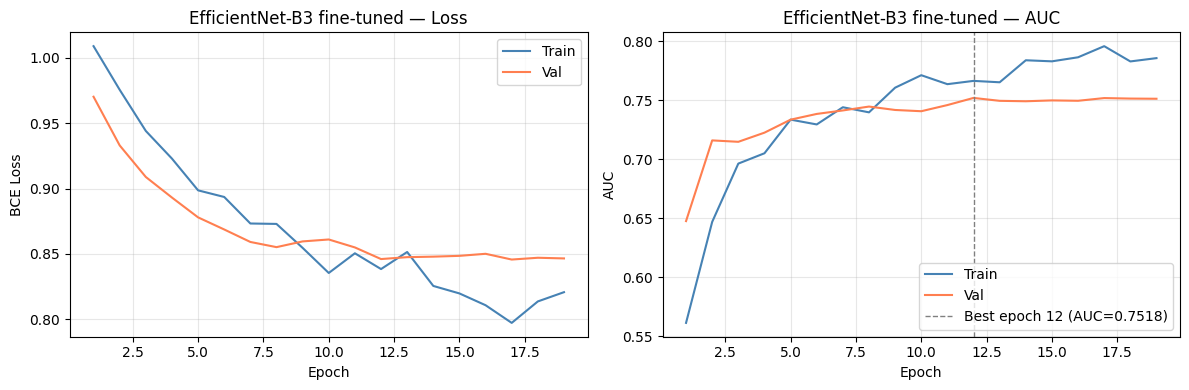

In [89]:
random.seed(42)
npr.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

ftNet, history_ft = train_model(
    ftNet,
    criterion,
    optimizer_ft,
    cos_lr_scheduler,
    num_epochs=NUM_EPOCHS_FT,
    patience=PATIENCE_FT,
    checkpoint_dir='checkpoints',
    run_name='ftNet',
)
plot_training_curves(history_ft, title='EfficientNet-B3 fine-tuned')

#### Exercise

The current solution uses Alexnet pre-trained on ImageNet and then fine-tunes it for our particular problem. You can try other networks, many of which come pre-trained in the ``torchvision`` package. For this, it is always necessary to adapt the last layers to our database, generating a probabilistic output score. You can find a guide at:

https://pytorch.org/tutorials/beginner/finetuning_torchvision_models_tutorial.html

In addition to the torchvision models, github and other repositories also have very competitive networks that could be useful.



In [90]:
!cp -r /content/cache_224 /content/drive/MyDrive/CV/cache_224/

^C


## Part 5: Evaluation (Important)
The evaluation of this practice will be done through a challenge, for which the students will have to send the results based on the test data in two categories:

- 1) CUSTOM Category: The results on the test set of a custom network, created from scratch by the students. In this case, the complete code of the network must appear in cells of the notebook and it will not be possible to make use of external networks/packages or pre-trained models.

- 2) FINE-TUNING Category: The results on the test set of a network that has been previously initialized in another database (with fine-tuning). In this case, existing models in torchvision or even external networks can be used.

In addition, the final mark will depend both on the results in both categories and on the content of a brief report (1 side for the description, 1 side for extra material: tables, figures and references) where they will describe the most important aspects of the proposed solutions. The objective of this report is for the teacher to assess the developments/extensions/decisions made by the students when optimizing their system. You do not need to provide an absolute level of detail about the changes made, just list them and briefly discuss the purpose of the changes.

### Details of the material to send for evaluation:

One zip file will be uploaded per group with the following contents:

- Two .csv files with the test outputs of the models that have trained in the two categories. Each file will contain a matrix of size 1000x1, with the DR score for each of the 1000 images in the test dataset. The array should be provided in text format (with 1 number per row). Code to generate the outputs is provided later.

- The report as described above.

- The notebook that integrates the creation of both models so that the teacher can check how things have been implemented.

**The deadline for submission of your results + the report is Tuesday Apr 21 at 23:59.**


Next we provide some functions that allow to test the network and create the csv file with the outputs.


In [93]:
### Code that generates the test matrix
def test_model(model):
    since = time.time()


    model.eval()   # Ponemos el modelo en modo evaluaciÃ³n

    #TamaÃ±o del dataset
    numSamples = len(test_dataset)

    # Creamos las variables que almacenarÃ¡n las salidas y las etiquetas
    outputs_m=np.zeros((numSamples,1),dtype=float)
    labels_m=np.zeros((numSamples,),dtype=int)
    contSamples=0

    # Iteramos sobre los datos
    for sample in test_dataloader:
        inputs = sample['image'].to(device).float()


        #Tamaño del batch
        batchSize = inputs.shape[0]

        # Paso forward
        with torch.torch.no_grad():
            outputs = model(inputs)

            #Aplicamos un softmax a la salida
            outputs=F.sigmoid(outputs)
            outputs_m [contSamples:contSamples+batchSize,:]=outputs.cpu().numpy()
            contSamples+=batchSize


    return outputs_m

Running the previous function and obtaining the matrix with the scores of the class 1 (Nx1)

In [96]:
outputs_custom = test_model(customNet)

outputs_ft = test_model(ftNet)

And finally save the matrix into a csv file

In [97]:
# Confirm both output arrays have shape (1000, 1) before writing CSVs
print('Custom net output shape:', outputs_custom.shape)
print('Fine-tuned net output shape:', outputs_ft.shape)

Custom net output shape: (1000, 1)
Fine-tuned net output shape: (1000, 1)


In [98]:
import csv

with open('output_custom.csv', mode='w') as out_file:
    csv_writer = csv.writer(out_file, delimiter=',')
    csv_writer.writerows(outputs_custom)


with open('output_ft.csv', mode='w') as out_file:
    csv_writer = csv.writer(out_file, delimiter=',')
    csv_writer.writerows(outputs_ft)

In [99]:
# Sanity check: run both models on the validation set (labels known) and report AUC
def eval_val_auc(model, name):
    model.eval()
    n = len(val_dataset)
    scores_m = np.zeros((n, 1), dtype=float)
    labels_m = np.zeros((n,),   dtype=int)
    cont = 0
    with torch.no_grad():
        for sample in val_dataloader:
            inputs = sample['image'].to(device).float()
            bs  = inputs.shape[0]
            out = torch.sigmoid(model(inputs))
            scores_m[cont:cont+bs, :] = out.cpu().numpy()
            labels_m[cont:cont+bs]    = sample['label'].numpy()
            cont += bs
    auc = metrics.roc_auc_score(labels_m, scores_m)
    print(f'{name} -- val AUC: {auc:.4f}')
    return auc

auc_custom = eval_val_auc(customNet, 'CustomNet')
auc_ft     = eval_val_auc(ftNet,     'EfficientNet-B3 fine-tuned')

CustomNet -- val AUC: 0.6428
EfficientNet-B3 fine-tuned -- val AUC: 0.7518


Finally, we will store the two CSV files in a ZIP archive, which will be the one uploaded to the Codabench platform whenever we want to participate in the competition (maximum of 2 submissions per day and 100 in total).

In [100]:
from zipfile import ZipFile

# Create a ZipFile Object
with ZipFile('./codabench_submission.zip', 'w') as zip_object:
   # Adding files that need to be zipped
   zip_object.write('./output_custom.csv')
   zip_object.write('./output_ft.csv')